## Zomato Chennai Data Analysis assignment

In [135]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import ast

warnings.filterwarnings("ignore")
pd.set_option("display.max_rows", None)

### 1. Importing dataset

In [136]:
chennai = pd.read_csv("Zomato Chennai Listing 2020.csv")

chennai.head()

,Zomato URL,Name of Restaurant,Address,Location,Cuisine,Top Dishes,Price for 2,Dining Rating,Dining Rating Count,Delivery Rating,Delivery Rating Count,Features
0,https://www.zomato.com/chennai/yaa-mohaideen-b...,Yaa Mohaideen Briyani,"336 & 338, Main Road, Pallavaram, Chennai",Pallavaram,['Biryani'],"['Bread Halwa', ' Chicken 65', ' Mutton Biryan...",500.0,4.3,1500,4.3,9306,"['Home Delivery', 'Indoor Seating']"
1,https://www.zomato.com/chennai/sukkubhai-biriy...,Sukkubhai Biriyani,"New 14, Old 11/3Q, Railway Station Road, MKN ...",Alandur,"['Biryani', ' North Indian', ' Mughlai', ' Des...","['Beef Biryani', ' Beef Fry', ' Paratha', ' Pa...",1000.0,4.4,3059,4.1,39200,"['Home Delivery', 'Free Parking', 'Table booki..."
2,https://www.zomato.com/chennai/ss-hyderabad-bi...,SS Hyderabad Biryani,"98/339, Arcot Road, Opposite Gokulam Chit Fun...",Kodambakkam,"['Biryani', ' North Indian', ' Chinese', ' Ara...","['Brinjal Curry', ' Tandoori Chicken', ' Chick...",500.0,4.3,1361,4.4,10500,"['Home Delivery', 'Indoor Seating']"
3,https://www.zomato.com/chennai/kfc-perambur,KFC,"10, Periyar Nagar, 70 Feet Road, Near Sheeba ...",Perambur,"['Burger', ' Fast Food', ' Finger Food', ' Bev...",['Zinger Burger'],500.0,4.0,1101,4.0,11200,"['Home Delivery', 'Free Parking', 'Card Upon D..."
4,https://www.zomato.com/chennai/tasty-kitchen-p...,Tasty Kitchen,"135B, SRP Colony, Peravallur, Near Perambur, ...",Perambur,"['Chinese', ' Biryani', ' North Indian', ' Che...","['Mutton Biryani', ' Chicken Rice', ' Tomato R...",450.0,4.2,617,4.1,22400,"['Home Delivery', 'Indoor Seating']"


In [137]:
chennai.shape

(12032, 12)

In [138]:
chennai.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12032 entries, 0 to 12031
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Zomato URL             12032 non-null  object 
 1   Name of Restaurant     12032 non-null  object 
 2   Address                12032 non-null  object 
 3   Location               12032 non-null  object 
 4   Cuisine                12032 non-null  object 
 5   Top Dishes             12032 non-null  object 
 6   Price for 2            12032 non-null  float64
 7   Dining Rating          6681 non-null   float64
 8   Dining Rating Count    11812 non-null  object 
 9   Delivery Rating        6181 non-null   float64
 10  Delivery Rating Count  11812 non-null  object 
 11  Features               12032 non-null  object 
dtypes: float64(3), object(9)
memory usage: 1.1+ MB


In [139]:
chennai.describe(include="all")

,Zomato URL,Name of Restaurant,Address,Location,Cuisine,Top Dishes,Price for 2,Dining Rating,Dining Rating Count,Delivery Rating,Delivery Rating Count,Features
count,12032,12032,12032,12032,12032,12032,12032.000000,6681.000000,11812,6181.000000,11812,12032
unique,12032,8369,10828,268,2423,2190,NaN,NaN,793,NaN,2281,1554
top,https://www.zomato.com/chennai/yaa-mohaideen-b...,Amma Unavagam,Delivery Only,Porur,['South Indian'],Invalid,NaN,NaN,Does not offer Dining,NaN,Not enough Delivery Reviews,"['Home Delivery', 'Indoor Seating']"
freq,1,78,443,418,883,9641,NaN,NaN,2603,NaN,3379,2447
mean,NaN,NaN,NaN,NaN,NaN,NaN,397.611370,3.387756,NaN,3.805290,NaN,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,332.045938,0.558181,NaN,0.374213,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,40.000000,0.300000,NaN,0.300000,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,200.000000,3.100000,NaN,3.600000,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,300.000000,3.500000,NaN,3.900000,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,450.000000,3.800000,NaN,4.000000,NaN,NaN


## 2. Cleaning the Dataset

### a. Renaming columns and checking for duplicates

In [140]:
chennai = chennai.rename(columns={"Zomato URL": "URL", "Name of Restaurant": "NAME", "Address": "ADDRESS", "Location": "REGION",
    "Cuisine": "CUSINE_CATEGORY", "Top Dishes": "TOP_DISHES", "Price for 2": "PRICE", "Dining Rating": "RATING", "Dining Rating Count": "VOTES",
    "Delivery Rating": "DELIVERY_RATING", "Delivery Rating Count": "DELIVERY_VOTES", "Features": "FEATURES"})

chennai[chennai.duplicated()].head()

,URL,NAME,ADDRESS,REGION,CUSINE_CATEGORY,TOP_DISHES,PRICE,RATING,VOTES,DELIVERY_RATING,DELIVERY_VOTES,FEATURES


In [141]:
chennai.duplicated().sum()

np.int64(0)

### b. Handling nan values in rating column

In [142]:
# Convert text-based count fields to numeric values.
count_fix_map = {
    "Does not offer Dining": 0,
    "Not enough Dining Reviews": 0,
    "Does not offer Delivery": 0,
    "Not enough Delivery Reviews": 0
}

chennai["VOTES"] = chennai["VOTES"].replace(count_fix_map)
chennai["DELIVERY_VOTES"] = chennai["DELIVERY_VOTES"].replace(count_fix_map)

chennai["PRICE"] = pd.to_numeric(chennai["PRICE"], errors="coerce")
chennai["RATING"] = pd.to_numeric(chennai["RATING"], errors="coerce")
chennai["DELIVERY_RATING"] = pd.to_numeric(chennai["DELIVERY_RATING"], errors="coerce")

chennai["VOTES"] = pd.to_numeric(chennai["VOTES"], errors="coerce").fillna(0).astype(int)
chennai["DELIVERY_VOTES"] = pd.to_numeric(chennai["DELIVERY_VOTES"], errors="coerce").fillna(0).astype(int)

chennai.isnull().sum()

URL                   0
NAME                  0
ADDRESS               0
REGION                0
CUSINE_CATEGORY       0
TOP_DISHES            0
PRICE                 0
RATING             5351
VOTES                 0
DELIVERY_RATING    5851
DELIVERY_VOTES        0
FEATURES              0
dtype: int64

### c. Creating cuisine type and rating type columns

In [143]:
def take_first_cuisine(value):
    try:
        parsed = ast.literal_eval(value)
        if isinstance(parsed, list) and len(parsed) > 0:
            return str(parsed[0]).strip()
    except Exception:
        pass
    return str(value).strip()

def bucket_rating(score):
    if score >= 4.5:
        return "Excellent"
    elif score >= 4.0:
        return "Very Good"
    elif score >= 3.5:
        return "Good"
    elif score >= 3.0:
        return "Average"
    elif score > 0:
        return "Poor"
    else:
        return "Very Poor"

chennai["CUSINE TYPE"] = chennai["CUSINE_CATEGORY"].apply(take_first_cuisine)
chennai["RATING TYPE"] = chennai["RATING"].apply(bucket_rating)

chennai[["NAME", "PRICE", "CUSINE_CATEGORY", "REGION", "CUSINE TYPE", "RATING", "VOTES", "RATING TYPE"]].head()

,NAME,PRICE,CUSINE_CATEGORY,REGION,CUSINE TYPE,RATING,VOTES,RATING TYPE
0,Yaa Mohaideen Briyani,500.0,['Biryani'],Pallavaram,Biryani,4.3,1500,Very Good
1,Sukkubhai Biriyani,1000.0,"['Biryani', ' North Indian', ' Mughlai', ' Des...",Alandur,Biryani,4.4,3059,Very Good
2,SS Hyderabad Biryani,500.0,"['Biryani', ' North Indian', ' Chinese', ' Ara...",Kodambakkam,Biryani,4.3,1361,Very Good
3,KFC,500.0,"['Burger', ' Fast Food', ' Finger Food', ' Bev...",Perambur,Burger,4.0,1101,Very Good
4,Tasty Kitchen,450.0,"['Chinese', ' Biryani', ' North Indian', ' Che...",Perambur,Chinese,4.2,617,Very Good


### d. Dropping unused columns and keeping only useful fields

In [144]:
chennai = chennai.drop(
    columns=["URL", "ADDRESS", "TOP_DISHES", "DELIVERY_RATING", "DELIVERY_VOTES", "FEATURES"]
)

# Remove restaurant records with zero rating or zero votes
bad_rows = (chennai["RATING"] == 0) | (chennai["VOTES"] == 0)
chennai = chennai[~bad_rows]

chennai = chennai.drop_duplicates()
chennai.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6661 entries, 0 to 11802
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   NAME             6661 non-null   object 
 1   REGION           6661 non-null   object 
 2   CUSINE_CATEGORY  6661 non-null   object 
 3   PRICE            6661 non-null   float64
 4   RATING           6661 non-null   float64
 5   VOTES            6661 non-null   int64  
 6   CUSINE TYPE      6661 non-null   object 
 7   RATING TYPE      6661 non-null   object 
dtypes: float64(2), int64(1), object(5)
memory usage: 468.4+ KB


### e. Copying the cleaned data to a new DataFrame

In [145]:
chennai_df = chennai.copy()
chennai_df.head()

,NAME,REGION,CUSINE_CATEGORY,PRICE,RATING,VOTES,CUSINE TYPE,RATING TYPE
0,Yaa Mohaideen Briyani,Pallavaram,['Biryani'],500.0,4.3,1500,Biryani,Very Good
1,Sukkubhai Biriyani,Alandur,"['Biryani', ' North Indian', ' Mughlai', ' Des...",1000.0,4.4,3059,Biryani,Very Good
2,SS Hyderabad Biryani,Kodambakkam,"['Biryani', ' North Indian', ' Chinese', ' Ara...",500.0,4.3,1361,Biryani,Very Good
3,KFC,Perambur,"['Burger', ' Fast Food', ' Finger Food', ' Bev...",500.0,4.0,1101,Burger,Very Good
4,Tasty Kitchen,Perambur,"['Chinese', ' Biryani', ' North Indian', ' Che...",450.0,4.2,617,Chinese,Very Good


## 3. Performing Exploratory Data Analysis [EDA]

### Q1) How many restaurants are in Chennai for each type of cuisine?

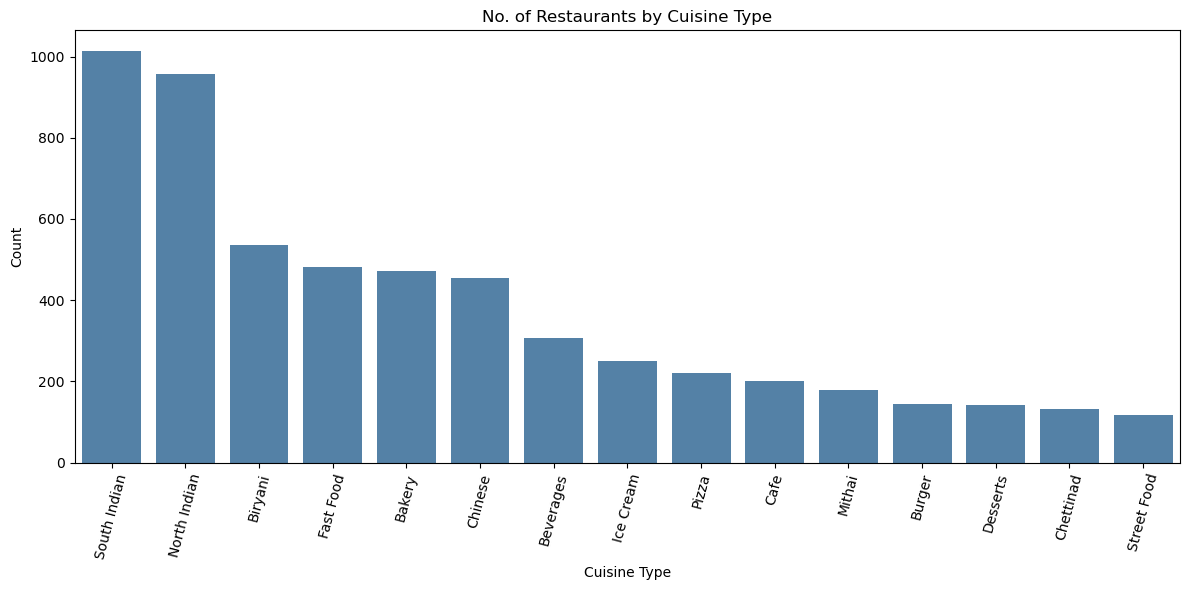

In [146]:
cuisine_count_df = chennai_df["CUSINE TYPE"].value_counts().reset_index()
cuisine_count_df.columns = ["CUSINE TYPE", "COUNT"]

plt.figure(figsize=(12, 6))
sns.barplot(data=cuisine_count_df.head(15), x="CUSINE TYPE", y="COUNT", color="steelblue")
plt.xticks(rotation=75)
plt.title("No. of Restaurants by Cuisine Type")
plt.xlabel("Cuisine Type")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

### Q2) What are the percentage of restaurants by Rating Type in Chennai?

In [147]:
rating_type_df = chennai_df["RATING TYPE"].value_counts().reset_index(name="COUNT OF RESTAURANTS")
rating_type_df.rename(columns={"index": "RATING TYPE"}, inplace=True)
rating_type_df

,RATING TYPE,COUNT OF RESTAURANTS
0,Good,2501
1,Average,2054
2,Poor,1215
3,Very Good,815
4,Excellent,76


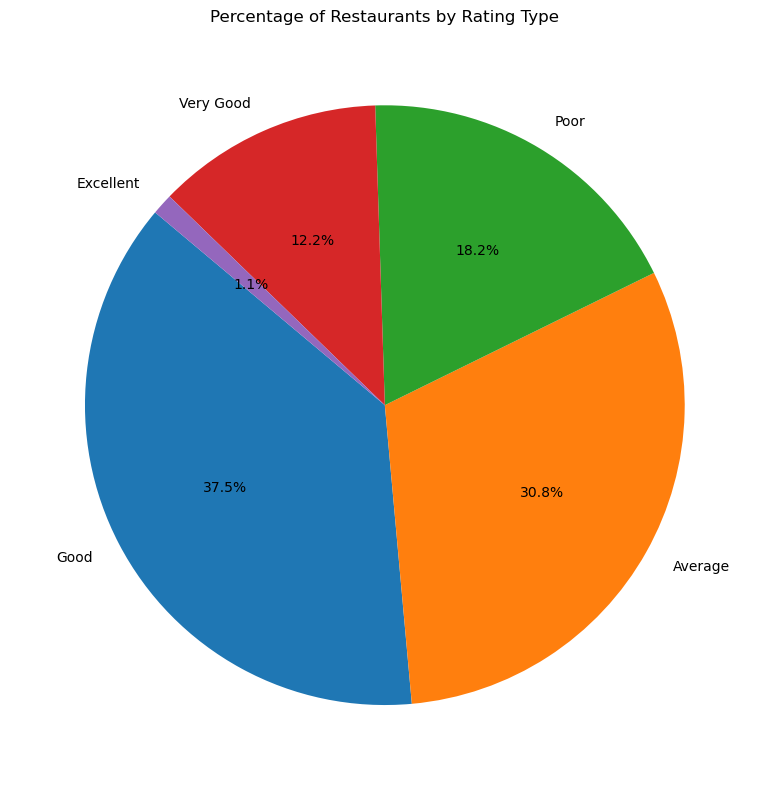

In [148]:
plt.figure(figsize=(8, 8))
plt.pie(
    rating_type_df["COUNT OF RESTAURANTS"],
    labels=rating_type_df["RATING TYPE"],
    autopct="%1.1f%%",
    startangle=140
)
plt.title("Percentage of Restaurants by Rating Type")
plt.tight_layout()
plt.show()

### Q3) Which are the Top 10 highest rated Seafood Restaurant in Chennai?

In [149]:
seafood_df = chennai_df[chennai_df["CUSINE_CATEGORY"].str.contains("Seafood", na=False)]
seafood_df.sort_values(by="RATING", ascending=False).head(10)

,NAME,REGION,CUSINE_CATEGORY,PRICE,RATING,VOTES,CUSINE TYPE,RATING TYPE
195,The Marina,Nungambakkam,"['Seafood', ' North Indian', ' Chinese']",1600.0,4.8,1082,Seafood,Excellent
292,Alchemy Bar & Lounge,"Hotel Rajpark, Alwarpet","['Continental', ' Finger Food', ' Seafood', ' ...",2000.0,4.5,432,Continental,Excellent
214,Sera - The Tapas Bar & Restaurant,Gopalapuram,"['Finger Food', ' Seafood', ' Italian', ' Cont...",1600.0,4.5,964,Finger Food,Excellent
358,The Wharf 2.0 - Radisson BLU Templebay,"Radisson Blu Temple Bay, Mamallapuram","['Seafood', ' Mediterranean', ' Italian', ' No...",3000.0,4.4,517,Seafood,Very Good
342,L'attitude 49,Grande Bay Resort,"['Singaporean', ' Thai', ' Asian', ' Chinese',...",1800.0,4.4,563,Singaporean,Very Good
315,Layalee,Ekkaduthangal,"['Arabian', ' BBQ', ' Seafood', ' Chinese', ' ...",700.0,4.4,586,Arabian,Very Good
282,Bay View - Taj Fisherman's Cove Resort & Spa,"Taj Fisherman's Cove Resort & Spa, Kanchipuram...","['Seafood', ' South Indian', ' Andhra', ' Kera...",3500.0,4.4,678,Seafood,Very Good
96,Urban Spatula,Anna Nagar West,"['Continental', ' Seafood', ' Biryani', ' Ital...",800.0,4.4,794,Continental,Very Good
14,Hotel Paramount,Kilpauk,"['North Indian', ' Chinese', ' Seafood', ' Sou...",500.0,4.3,1266,North Indian,Very Good
153,The Bayleaf,Gopalapuram,"['Mughlai', ' North Indian', ' Seafood', ' Bir...",800.0,4.3,542,Mughlai,Very Good


### Q4) Which is the best Fast Food Restaurant in Chennai?

In [150]:
fastfood_df = chennai_df[chennai_df["CUSINE TYPE"] == "Fast Food"]
fastfood_df.sort_values(by="RATING", ascending=False).head(10)

,NAME,REGION,CUSINE_CATEGORY,PRICE,RATING,VOTES,CUSINE TYPE,RATING TYPE
178,Royal Sandwich Shop,Alwarpet,"['Fast Food', ' Desserts', ' Beverages']",150.0,4.7,1304,Fast Food,Excellent
75,Fusilli Reasons,Kilpauk,['Fast Food'],400.0,4.7,3042,Fast Food,Excellent
177,Basil With A Twist,T. Nagar,"['Fast Food', ' Italian', ' Salad']",1500.0,4.6,2102,Fast Food,Excellent
9338,Royal Sandwich Shop,Kotturpuram,"['Fast Food', ' Desserts', ' Beverages']",150.0,4.4,318,Fast Food,Very Good
318,Cheesy Juicy Burgers,Anna Nagar East,"['Fast Food', ' Sandwich', ' Burger', ' Bevera...",400.0,4.3,588,Fast Food,Very Good
179,Links,Purasavakkam,"['Fast Food', ' Street Food']",250.0,4.3,695,Fast Food,Very Good
420,Signal Tod Cafe,"OMR Food Street, Guduvancheri",['Fast Food'],250.0,4.3,445,Fast Food,Very Good
393,The Bombay Fries,Nungambakkam,['Fast Food'],500.0,4.2,452,Fast Food,Very Good
495,Galito's,Velachery,"['Fast Food', ' Portuguese']",1000.0,4.2,316,Fast Food,Very Good
167,Pupil,"TNHB Complex, Besant Nagar","['Fast Food', ' Chinese', ' North Indian', ' B...",650.0,4.2,847,Fast Food,Very Good


### Q5) Which places have the highest rated restaurant for each Cuisine Type in Chennai?

In [151]:
highest_rated_df = chennai_df[chennai_df["RATING"] >= 4.5]
highest_rated_df.sort_values(by="RATING", ascending=False).head()

,NAME,REGION,CUSINE_CATEGORY,PRICE,RATING,VOTES,CUSINE TYPE,RATING TYPE
184,Gossip Fusion Bistro,Kanathur,"['Italian', ' Continental', ' Burger', ' Sandw...",1500.0,4.9,996,Italian,Excellent
192,Kabab Corner,Egmore,"['Kebab', ' Rolls', ' Mughlai']",450.0,4.9,1053,Kebab,Excellent
57,Brownie Heaven,Royapettah,"['Bakery', ' Desserts', ' Beverages']",350.0,4.9,842,Bakery,Excellent
320,Bombay Kulfi,Adyar,['Ice Cream'],200.0,4.9,534,Ice Cream,Excellent
155,The Sandwich Shop,West Mambalam,"['Sandwich', ' Fast Food', ' Beverages']",300.0,4.9,584,Sandwich,Excellent


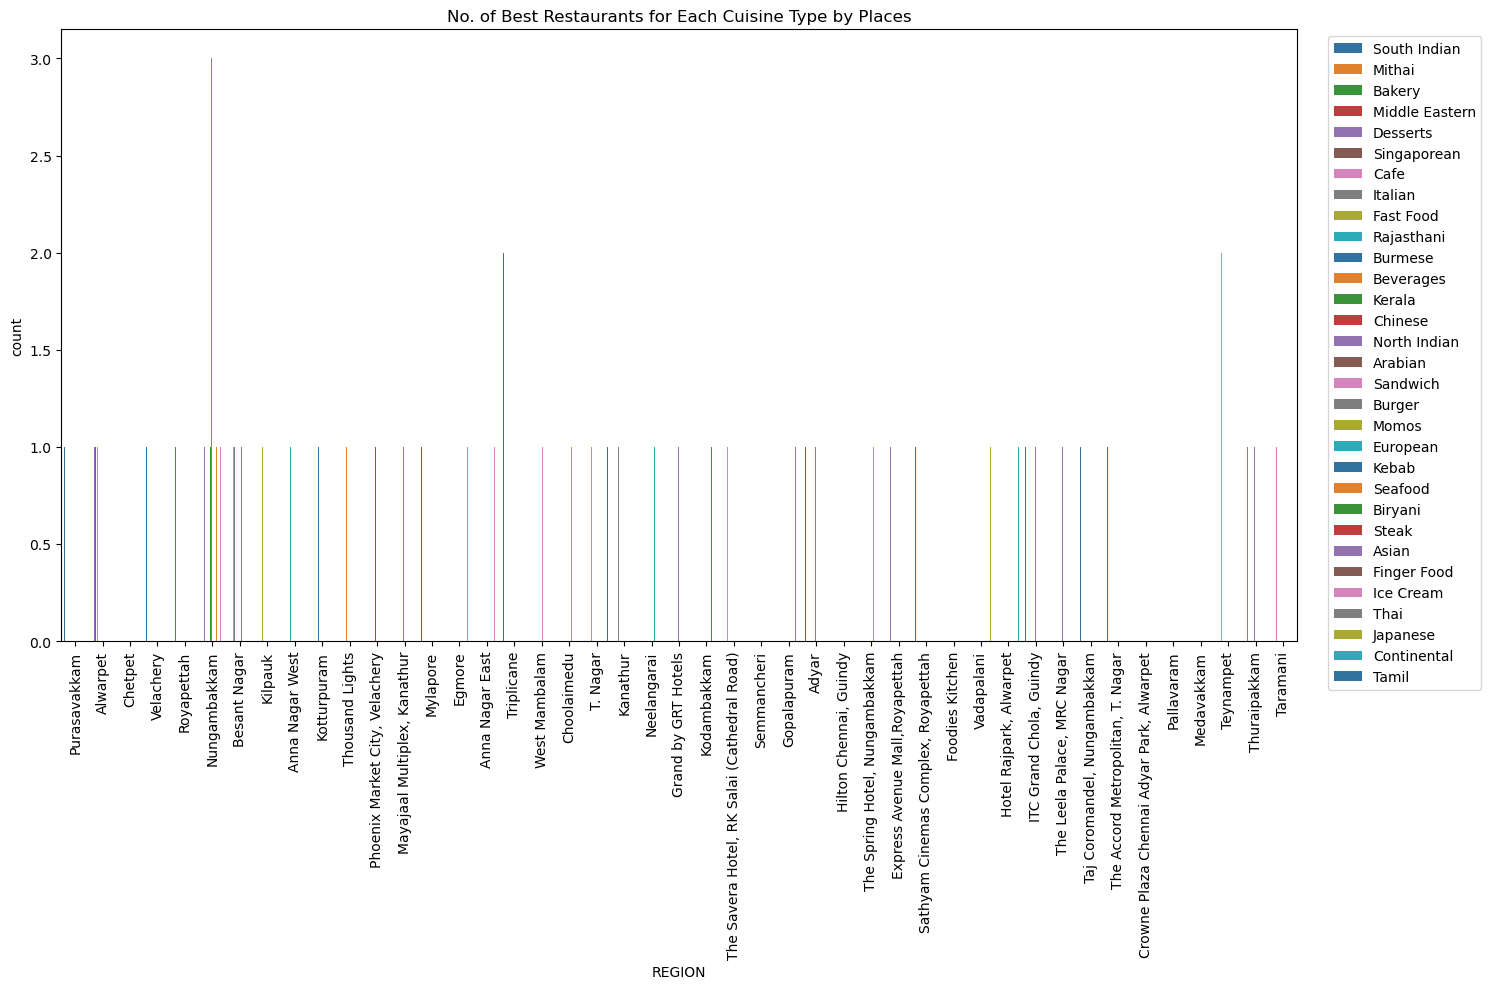

In [152]:
plt.figure(figsize=(15, 10))
sns.countplot(x="REGION", data=highest_rated_df, hue="CUSINE TYPE", palette="tab10")
plt.xticks(rotation=90)
plt.title("No. of Best Restaurants for Each Cuisine Type by Places")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

### Q6) What is the Avg Price Distribution of highest rated restaurant for each Cuisine Type in Chennai?

In [153]:
highest_rated_price_df = highest_rated_df.groupby(by=["REGION", "CUSINE TYPE"])["PRICE"].mean().reset_index()
highest_rated_price_df.head()

,REGION,CUSINE TYPE,PRICE
0,Adyar,Chinese,800.0
1,Adyar,Ice Cream,200.0
2,Adyar,North Indian,1800.0
3,Adyar,South Indian,500.0
4,Alwarpet,Desserts,350.0


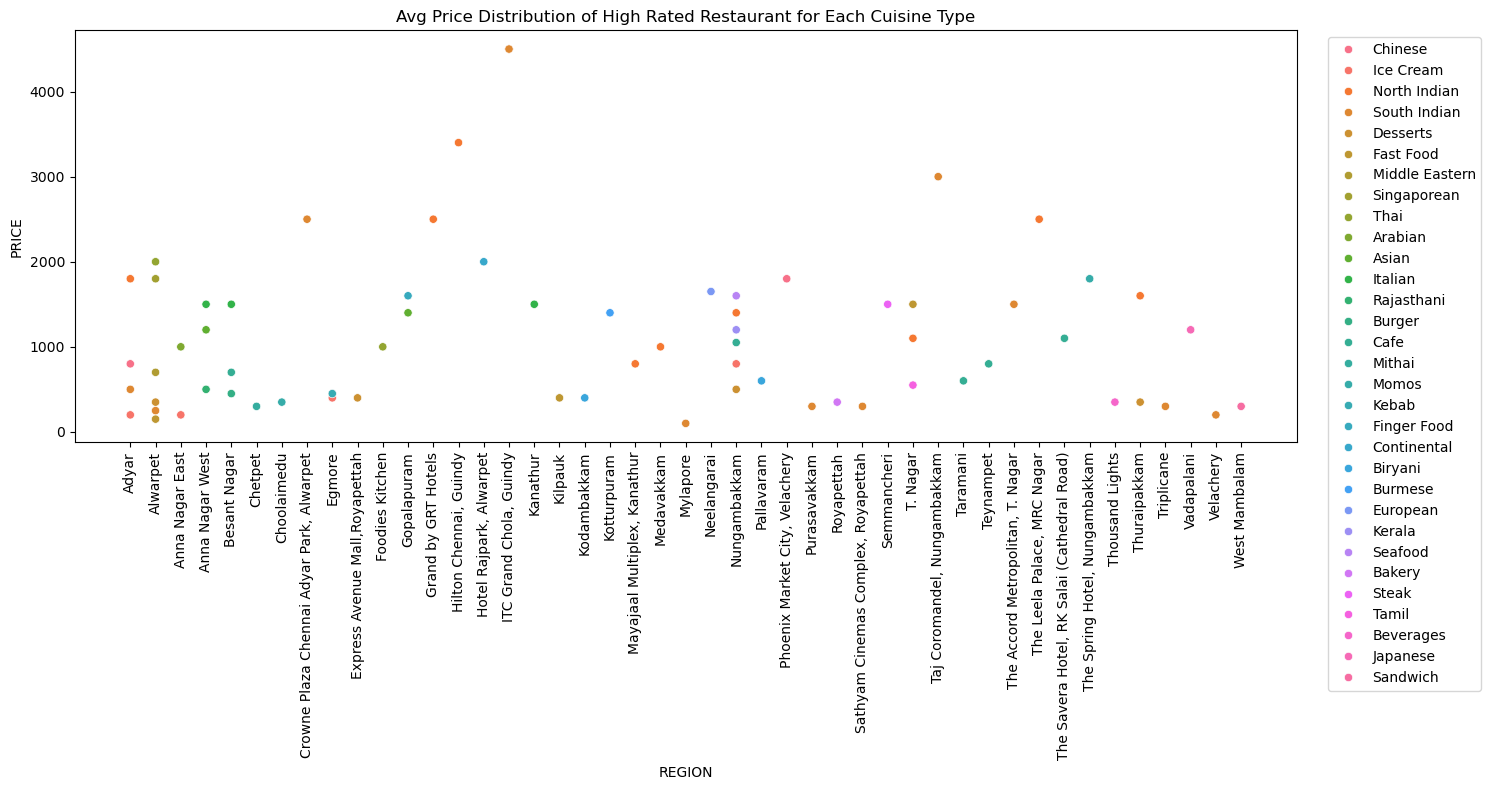

In [154]:
plt.figure(figsize=(15, 8))
sns.scatterplot(x="REGION", y="PRICE", hue="CUSINE TYPE", data=highest_rated_price_df)
plt.xticks(rotation=90)
plt.title("Avg Price Distribution of High Rated Restaurant for Each Cuisine Type")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

### Q7) Which areas have a large number of Chinese Restaurant Market?

In [155]:
chinese_df = chennai_df[chennai_df["CUSINE_CATEGORY"].str.contains("Chinese", na=False)]
chinese_rest_df = chinese_df.groupby(by="REGION").agg({"NAME": "count", "PRICE": "mean"}).rename(
    columns={"NAME": "COUNT OF RESTAURANTS"}
)
chinese_rest_df = chinese_rest_df.sort_values("COUNT OF RESTAURANTS", ascending=False).head(25)
chinese_rest_df.head()

,COUNT OF RESTAURANTS,PRICE
REGION,,
Porur,81,459.876543
T. Nagar,71,516.901408
Ambattur,68,402.941176
Perambur,66,446.212121
Anna Nagar East,66,613.636364


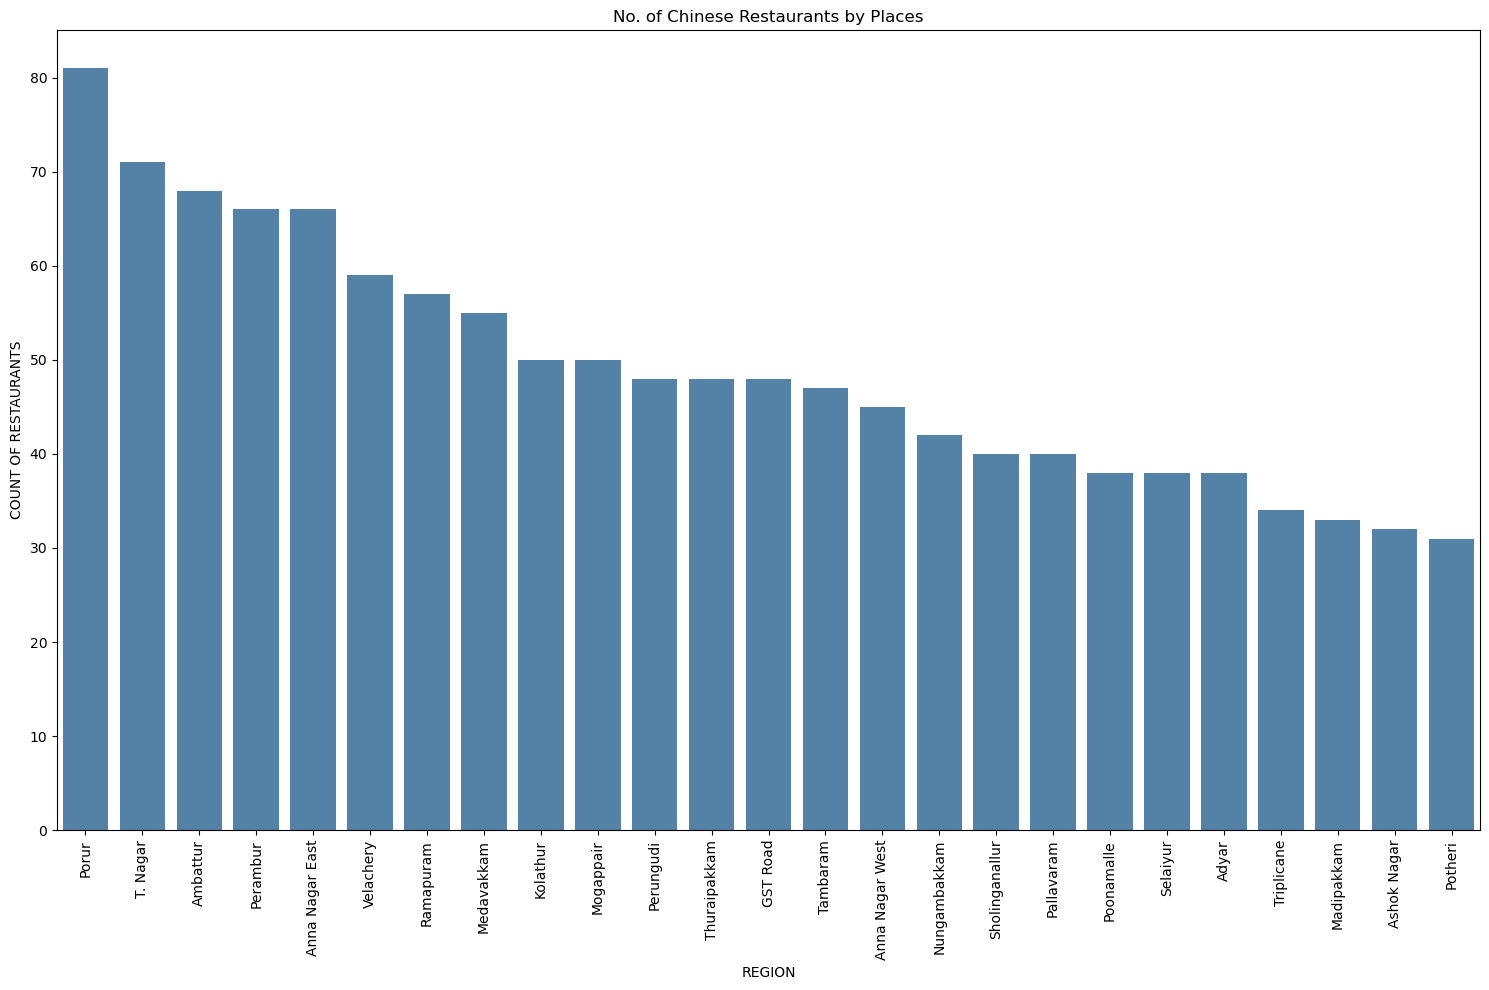

In [156]:
plt.figure(figsize=(15, 10))
sns.barplot(x="REGION", y="COUNT OF RESTAURANTS", data=chinese_rest_df, color="steelblue")
plt.xticks(rotation=90)
plt.title("No. of Chinese Restaurants by Places")
plt.tight_layout()
plt.show()

### Q8) Is there a relation between Price and Rating by each Cuisine Type?

In [157]:
price_rating_df = chennai_df.groupby(["CUSINE TYPE", "RATING"])["PRICE"].mean().reset_index()
price_rating_df.head()

,CUSINE TYPE,RATING,PRICE
0,American,2.4,800.0
1,American,2.7,300.0
2,American,3.3,250.0
3,American,3.9,600.0
4,American,4.1,1200.0


We compare average price trends across rating values for each cuisine type.

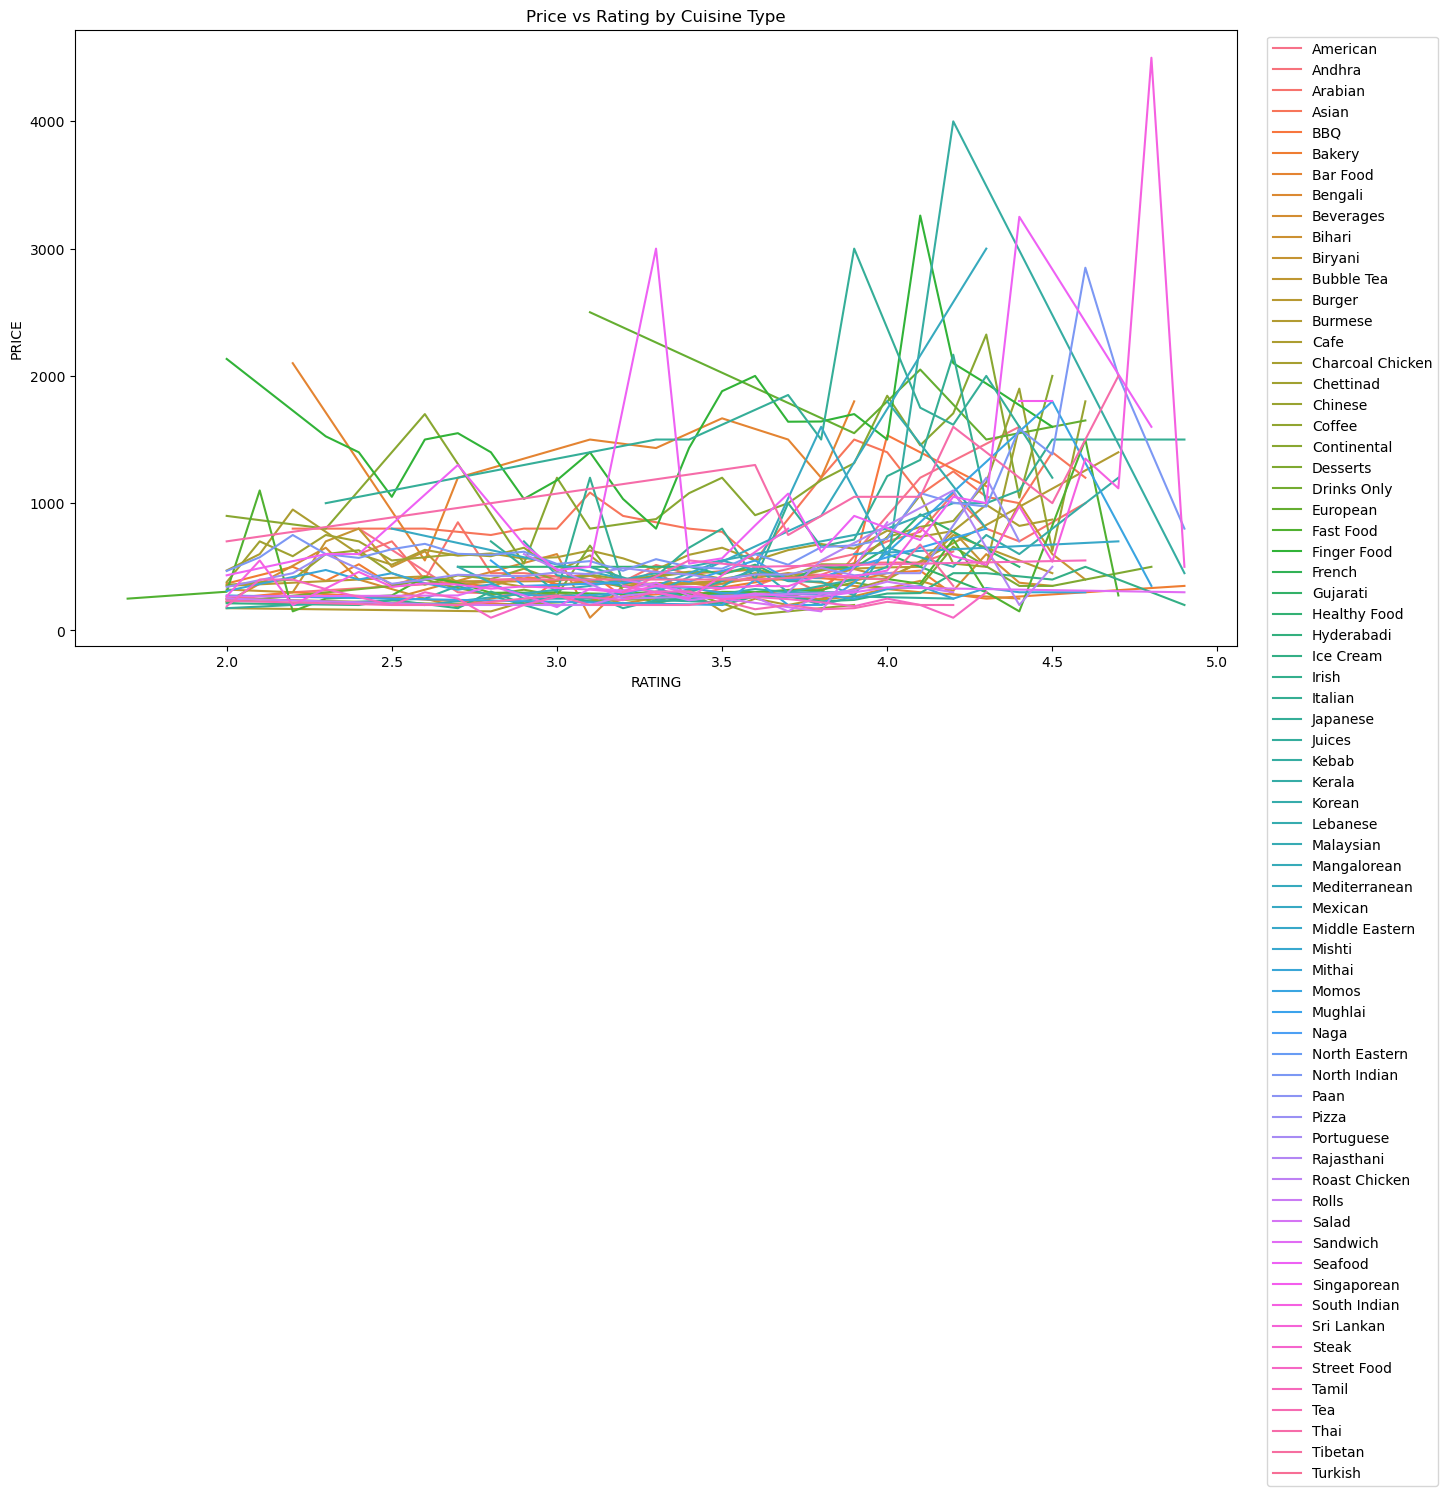

In [158]:
plt.figure(figsize=(15, 8))
sns.lineplot(data=price_rating_df, x="RATING", y="PRICE", hue="CUSINE TYPE")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.title("Price vs Rating by Cuisine Type")
plt.tight_layout()
plt.show()

### Q9) Is there a relation between Region and Price?

In [159]:
region_price_df = chennai_df.groupby(["REGION"])["PRICE"].mean().reset_index()
region_price_df.head()

,REGION,PRICE
0,InterContinental Chennai Mahabalipuram Resort...,1500.000000
1,Abhiramapuram,150.000000
2,"Abu Sarovar Portico, Egmore",1000.000000
3,Adambakkam,308.730159
4,Adyar,520.081967


The average price changes from one location to another.

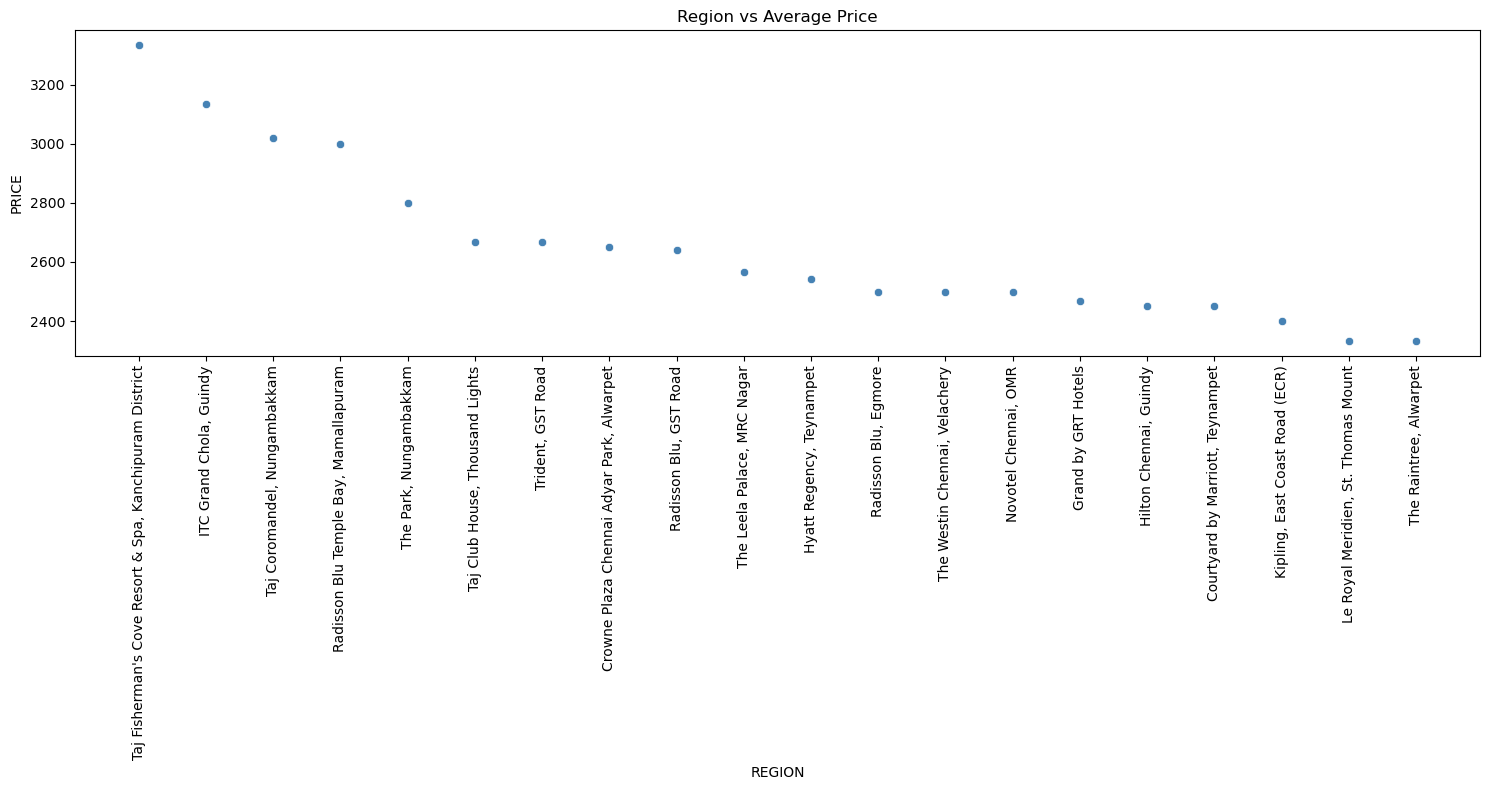

In [171]:
plt.figure(figsize=(15, 8))
sns.scatterplot(data=region_price_df, x="REGION", y="PRICE", color="steelblue")
plt.xticks(rotation=90)
plt.title("Region vs Average Price")
plt.tight_layout()
plt.show()

### Q10) Find the list of Affordable Restaurants?

In [161]:
max_price = chennai_df["PRICE"].max()
one_fourth_price = max_price / 4
one_fourth_price

1250.0

In [162]:
aff_rest_df = chennai_df[["NAME", "PRICE", "CUSINE_CATEGORY", "REGION", "CUSINE TYPE"]]
aff_rest_df = aff_rest_df[aff_rest_df["PRICE"] <= one_fourth_price]
aff_rest_df.sort_values(by="PRICE", inplace=True)
aff_rest_df.head()

,NAME,PRICE,CUSINE_CATEGORY,REGION,CUSINE TYPE
4685,Soda Hub,40.0,['Beverages'],"OMR Food Street, Navallur",Beverages
1448,Mamee Soup,60.0,['Healthy Food'],West Mambalam,Healthy Food
5047,Saraswathi Bhavan Bread House,100.0,"['Bakery', ' Street Food']",Nungambakkam,Bakery
108,Rayar's Mess,100.0,['South Indian'],Mylapore,South Indian
2773,Suriya Sweets,100.0,"['Mithai', ' Street Food']",RA Puram,Mithai


In [163]:
highrate_rest_df = chennai_df[["NAME", "PRICE", "CUSINE_CATEGORY", "REGION", "CUSINE TYPE", "RATING"]]
highrate_rest_df = highrate_rest_df[highrate_rest_df["RATING"] >= 4.5]
highrate_rest_df.sort_values(by="PRICE", inplace=True)
highrate_rest_df.head()

,NAME,PRICE,CUSINE_CATEGORY,REGION,CUSINE TYPE,RATING
108,Rayar's Mess,100.0,['South Indian'],Mylapore,South Indian,4.7
178,Royal Sandwich Shop,150.0,"['Fast Food', ' Desserts', ' Beverages']",Alwarpet,Fast Food,4.7
9541,Bombay Kulfi,200.0,['Ice Cream'],Anna Nagar East,Ice Cream,4.6
320,Bombay Kulfi,200.0,['Ice Cream'],Adyar,Ice Cream,4.9
50,Andhikkadai,200.0,['South Indian'],Velachery,South Indian,4.6


In [164]:
highrate_aff_df = pd.merge(aff_rest_df, highrate_rest_df, how="inner", on=["NAME", "REGION"])
highrate_aff_df = highrate_aff_df[["NAME", "PRICE_x", "CUSINE_CATEGORY_x", "REGION", "CUSINE TYPE_x"]]
highrate_aff_df.rename(
    columns={
        "PRICE_x": "PRICE",
        "CUSINE_CATEGORY_x": "CUSINE_CATEGORY",
        "CUSINE TYPE_x": "CUSINE TYPE"
    },
    inplace=True
)
highrate_aff_df.head()

,NAME,PRICE,CUSINE_CATEGORY,REGION,CUSINE TYPE
0,Rayar's Mess,100.0,['South Indian'],Mylapore,South Indian
1,Royal Sandwich Shop,150.0,"['Fast Food', ' Desserts', ' Beverages']",Alwarpet,Fast Food
2,Royal Sandwich Shop,150.0,"['Fast Food', ' Desserts', ' Beverages']",Alwarpet,Fast Food
3,Royal Sandwich Shop,150.0,"['Fast Food', ' Desserts', ' Beverages']",Alwarpet,Fast Food
4,Nair Mess,200.0,"['South Indian', ' Biryani']",Triplicane,South Indian


### Q11) Find the list of most Reliable Restaurants?
getting low priced, highly rated, and have votes above the average vote count.

In [165]:
mean_votes = chennai_df["VOTES"].mean()
mean_votes

np.float64(135.7671520792674)

In [166]:
mean_rest_df = chennai_df[["NAME", "PRICE", "CUSINE_CATEGORY", "REGION", "CUSINE TYPE", "VOTES"]]
mean_rest_df = mean_rest_df[mean_rest_df["VOTES"] >= mean_votes]
mean_rest_df.sort_values(by="PRICE", inplace=True)
mean_rest_df.head()

,NAME,PRICE,CUSINE_CATEGORY,REGION,CUSINE TYPE,VOTES
908,Gaurav Vada Pav Centre,100.0,['Street Food'],Perungudi,Street Food,188
1112,Jannal Kadai,100.0,['South Indian'],Mylapore,South Indian,153
108,Rayar's Mess,100.0,['South Indian'],Mylapore,South Indian,904
754,90ML,100.0,"['Tea', ' Coffee']",Nungambakkam,Tea,173
902,Kalathi Rose Milk Shop,150.0,['Beverages'],Mylapore,Beverages,190


In [167]:
reliable_rest_df = pd.merge(mean_rest_df, highrate_aff_df, how="inner", on=["NAME", "REGION"])
reliable_rest_df = reliable_rest_df[["NAME", "PRICE_x", "CUSINE_CATEGORY_x", "REGION", "CUSINE TYPE_x", "VOTES"]]
reliable_rest_df.rename(
    columns={
        "PRICE_x": "PRICE",
        "CUSINE_CATEGORY_x": "CUSINE_CATEGORY",
        "CUSINE TYPE_x": "CUSINE TYPE"
    },
    inplace=True
)
reliable_rest_df.head()

,NAME,PRICE,CUSINE_CATEGORY,REGION,CUSINE TYPE,VOTES
0,Rayar's Mess,100.0,['South Indian'],Mylapore,South Indian,904
1,Royal Sandwich Shop,150.0,"['Fast Food', ' Desserts', ' Beverages']",Alwarpet,Fast Food,1304
2,Royal Sandwich Shop,150.0,"['Fast Food', ' Desserts', ' Beverages']",Alwarpet,Fast Food,1304
3,Royal Sandwich Shop,150.0,"['Fast Food', ' Desserts', ' Beverages']",Alwarpet,Fast Food,1304
4,Andhikkadai,200.0,['South Indian'],Velachery,South Indian,908
